In [21]:
import matplotlib.pyplot as plt

In [ ]:
image = np.load("/media/g3/mahyar/Voxel_manipulation/environment_generation/generated_envs/image_0.npy")[0]

(1920, 1920, 3)

In [ ]:
from transformers import pipeline

generator = pipeline("mask-generation", model="facebook/sam2-hiera-large", device=0)

# image_url = "https://your-image.jpg"
outputs = generator("/media/g3/mahyar/Voxel_manipulation/segmentation/sample_segmentation_img.png", points_per_batch=64)

masks = outputs["masks"]  # list of boolean masks, one per detected object

Loading weights:   0%|          | 0/741 [00:00<?, ?it/s]

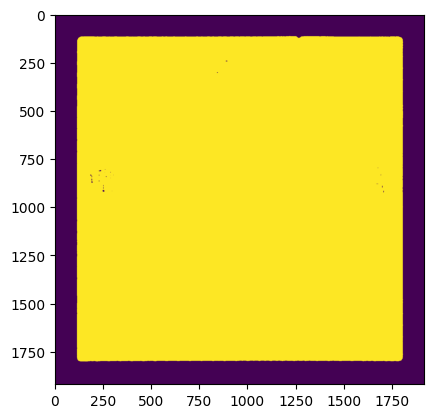

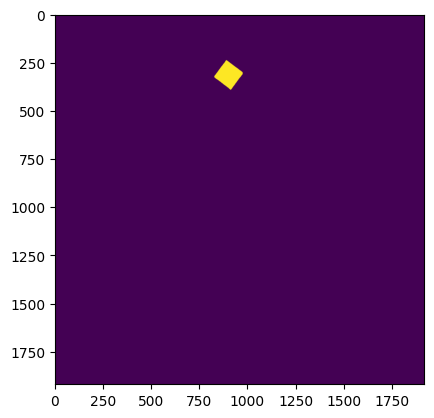

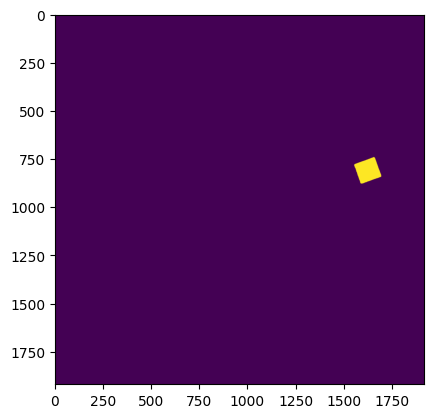

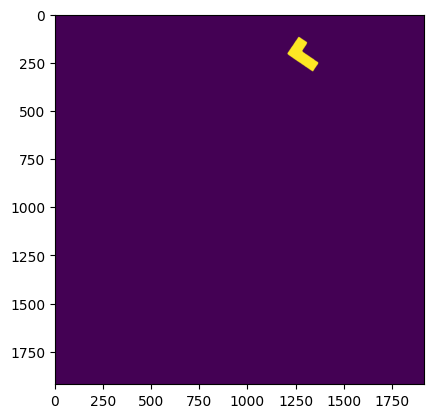

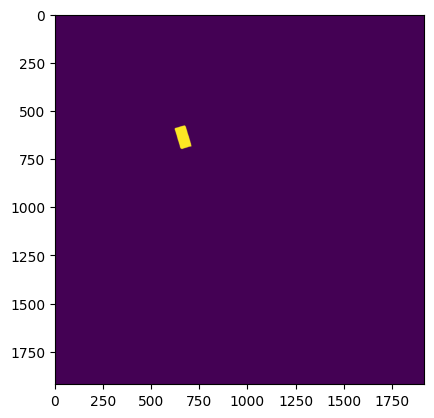

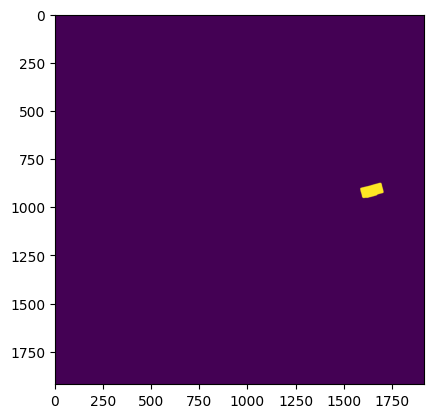

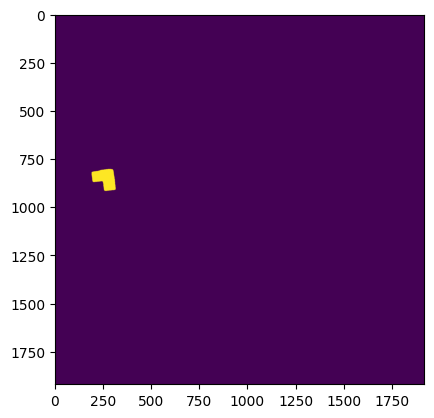

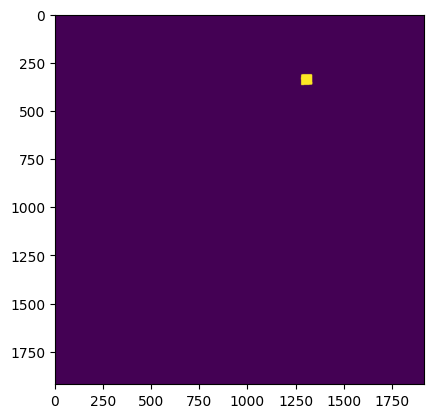

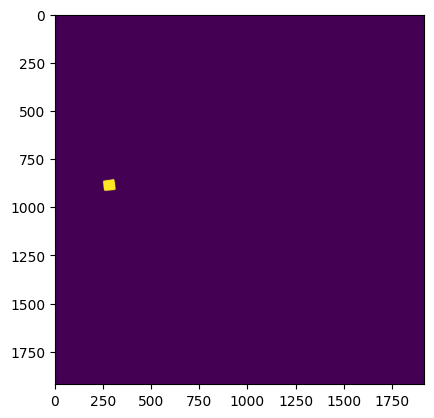

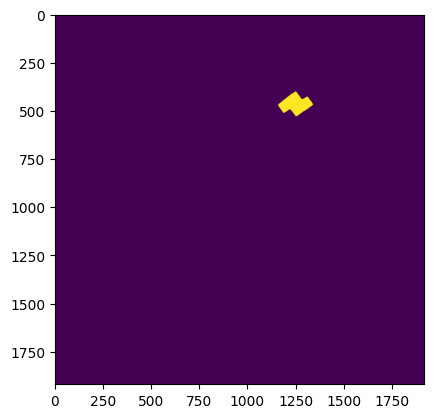

In [25]:
for i in masks:
    plt.imshow(i)
    plt.show()

In [46]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection, Sam2Processor, Sam2Model
import torch
from PIL import Image
import numpy as np

device = "cuda"

# --- Step 1: Grounding DINO (text → box) ---
dino_processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-base")
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained("IDEA-Research/grounding-dino-base").to(device)

image = Image.open("/media/g3/mahyar/Voxel_manipulation/segmentation/sample_segmentation_img.png").convert("RGB")

inputs = dino_processor(images=image, text="all the voxel shaped objects in the image with single color.", return_tensors="pt").to(device)
with torch.no_grad():
    outputs = dino_model(**inputs)

results = dino_processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    target_sizes=[image.size[::-1]]
)[0]

boxes = results["boxes"]  # shape (N, 4) in [x1, y1, x2, y2]
print(results["labels"])  # detected labels
print(boxes)

# --- Step 2: SAM 2 (box → precise mask) ---
sam_processor = Sam2Processor.from_pretrained("facebook/sam2-hiera-large")
sam_model = Sam2Model.from_pretrained("facebook/sam2-hiera-large").to(device)

inputs = sam_processor(
    images=image,
    input_boxes=[boxes.tolist()],   # pass DINO boxes as SAM prompts
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = sam_model(**inputs, multimask_output=False)

masks = sam_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"]
)[0]
# masks[i] = boolean mask for the i-th detected box

Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

['all the voxel', 'objects', 'all the voxel', 'objects', 'all the voxel', 'all the voxel', 'objects', 'objects', 'all the voxel', 'objects', 'the image', 'the voxel', 'the voxel', 'objects', 'objects']
tensor([[1541.2631,  732.8387, 1715.2397,  967.6728],
        [1542.0155,  733.1645, 1715.1218,  968.6010],
        [ 817.2377,  232.8875,  983.0009,  402.4225],
        [ 816.0470,  231.1317,  983.3538,  403.4223],
        [ 180.3262,  793.4064,  323.8978,  928.4292],
        [ 609.7355,  569.8563,  717.5605,  711.5996],
        [ 609.4752,  570.3088,  717.4623,  713.4999],
        [ 180.3282,  793.7339,  323.7021,  928.4671],
        [1265.5472,  295.5575, 1448.3398,  382.7619],
        [1266.5542,  297.8295, 1450.5474,  382.5868],
        [ 101.2247,  102.5523, 1824.1674, 1815.6105],
        [1147.6968,  395.1306, 1348.0540,  541.9865],
        [1197.0718,  112.3547, 1373.9487,  305.4968],
        [1147.7814,  395.7170, 1348.2020,  541.8571],
        [1197.4286,  112.1105, 1373.5953, 

You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/741 [00:00<?, ?it/s]

In [47]:
masks.shape

torch.Size([15, 1, 1920, 1920])

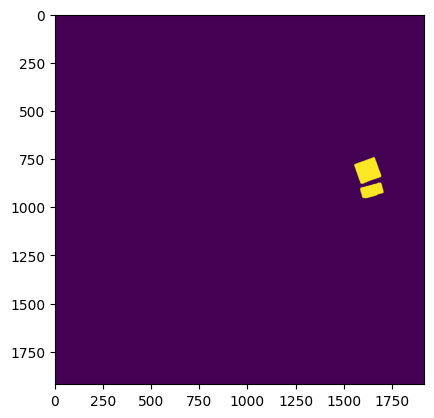

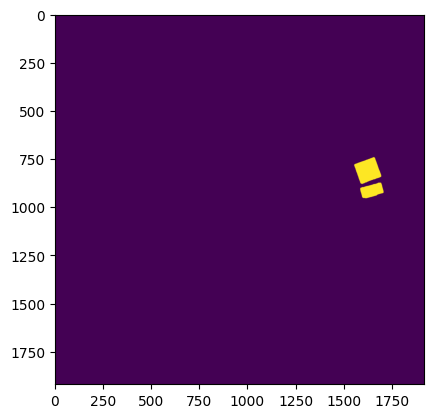

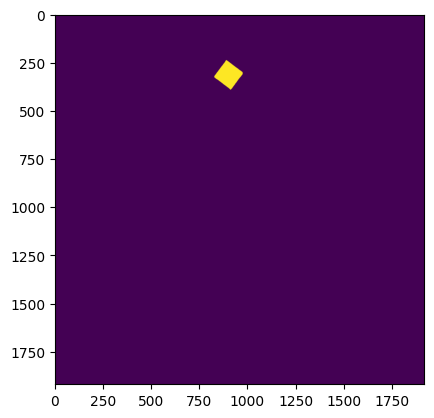

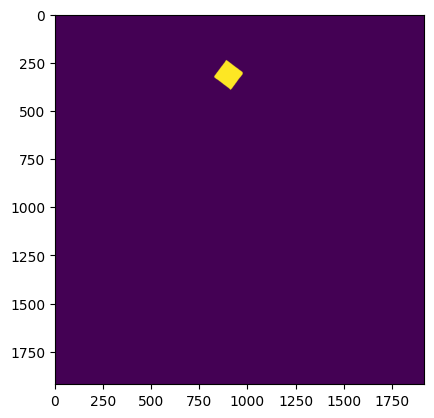

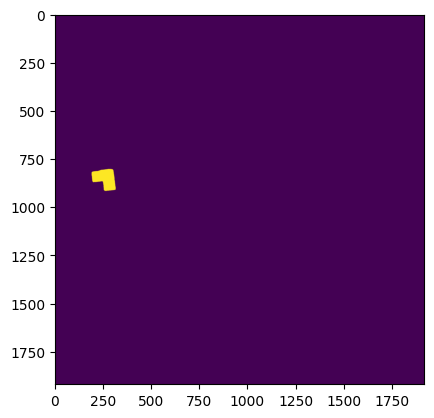

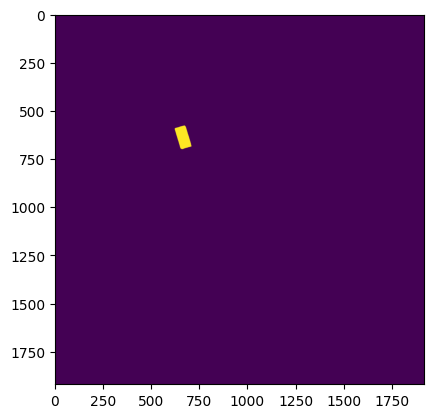

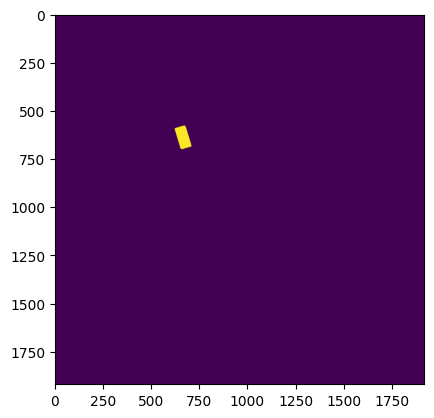

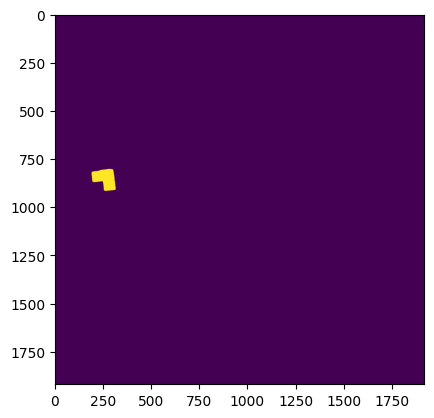

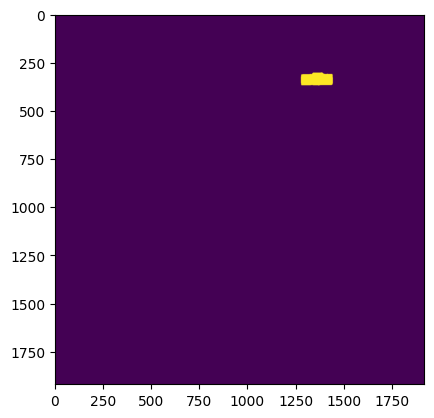

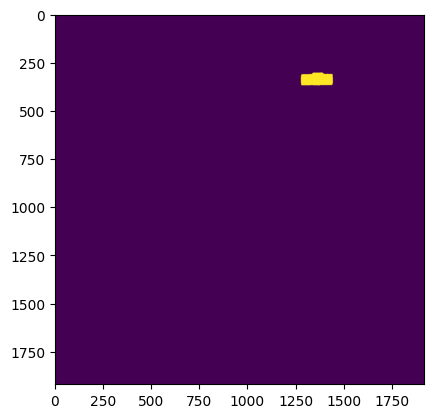

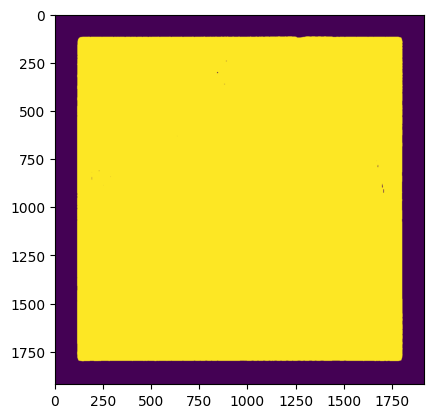

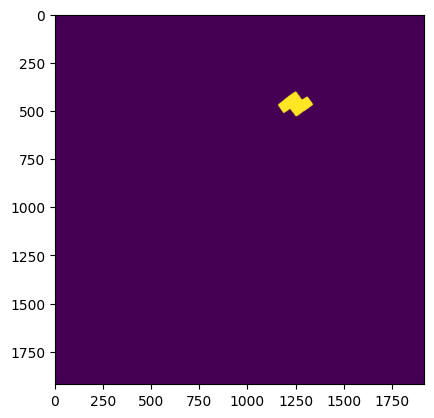

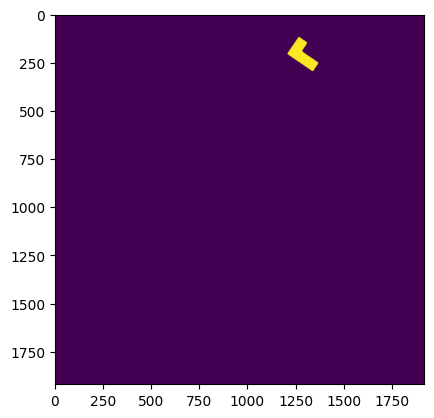

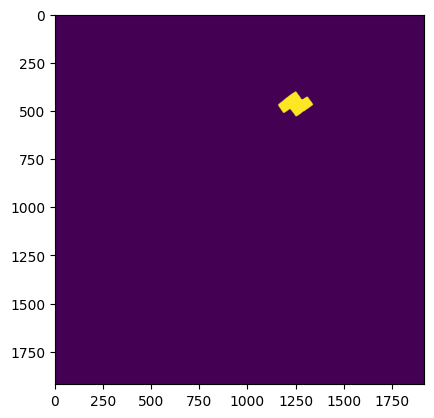

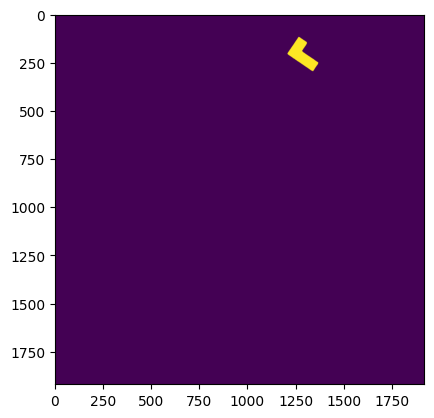

In [48]:
for i in masks:
    plt.imshow(i[0])
    plt.show()

In [51]:
image = Image.open("/media/g3/mahyar/Voxel_manipulation/segmentation/sample_segmentation_img.png").convert("RGB")

In [54]:
import torch
import numpy as np
from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor


model = build_sam3_image_model(
    device='cuda',
    eval_mode=True,
    load_from_HF=True,
)
model = model.float()  # force everything to float32 consistently

processor = Sam3Processor(model)

# image = Image.fromarray(np.load("/path/to/image_0.npy")[0]).convert("RGB")

with torch.no_grad():
    inference_state = processor.set_image(image)
    output = processor.set_text_prompt(state=inference_state, prompt="red cube")

masks  = output["masks"]
boxes  = output["boxes"]
scores = output["scores"]

print(f"Found {len(masks)} objects")
for i, (box, score) in enumerate(zip(boxes, scores)):
    print(f"  Object {i}: score={score:.3f}, box={box}")

RuntimeError: mat1 and mat2 must have the same dtype, but got BFloat16 and Float

In [58]:
from ultralytics import SAM

# Ultralytics will auto-download sam3.pt on first run
model = SAM("./sam3.pt")

# Then use it
results = model("/media/g3/mahyar/Voxel_manipulation/segmentation/sample_segmentation_img.png", texts=["red cube"])

FileNotFoundError: [Errno 2] No such file or directory: './sam3.pt'